# 02 · Predictive maintenance — FD001

This notebook grows block by block during Phase 1. **Block 1.2: features and leakage-safe validation.**

Decisions taken from notebook 01 (details in `docs/ml.md`):
- 14 sensors kept; the 6 constant sensors, the near-constant sensor 6 and the 3 operational settings are discarded.
- Sensor noise is large compared with the degradation trend until roughly the last 50–100 cycles, so the level of each sensor is smoothed.
- Units start at different levels, so each unit is compared with its own early-life baseline.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score

from industrial_ai.ml.data import SENSOR_DESCRIPTIONS, load_trajectories
from industrial_ai.ml.features import FeatureConfig, build_features
from industrial_ai.ml.labels import LABEL_COLUMN, add_failure_label, add_rul_train
from industrial_ai.ml.split import unit_group_kfold

HORIZON = 30
config = FeatureConfig()

train = add_failure_label(add_rul_train(load_trajectories("FD001", "train")), HORIZON)
features = build_features(train, config)
print(f"{features.shape[1]} features for {len(features):,} rows")
features.head()

42 features for 20,631 rows


,sensor_2_mean10,sensor_2_trend10,sensor_2_delta_baseline,sensor_3_mean10,sensor_3_trend10,sensor_3_delta_baseline,sensor_4_mean10,sensor_4_trend10,sensor_4_delta_baseline,sensor_7_mean10,...,sensor_15_delta_baseline,sensor_17_mean10,sensor_17_trend10,sensor_17_delta_baseline,sensor_20_mean10,sensor_20_trend10,sensor_20_delta_baseline,sensor_21_mean10,sensor_21_trend10,sensor_21_delta_baseline
0,641.820000,0.0,0.0,1589.700000,0.0,0.0,1400.600000,0.0,0.0,554.360000,...,0.0,392.000000,0.0,0.0,39.060000,0.0,0.0,23.419000,0.0,0.0
1,641.985000,0.0,0.0,1590.760000,0.0,0.0,1401.870000,0.0,0.0,554.055000,...,0.0,392.000000,0.0,0.0,39.030000,0.0,0.0,23.421300,0.0,0.0
2,642.106667,0.0,0.0,1589.836667,0.0,0.0,1402.646667,0.0,0.0,554.123333,...,0.0,391.333333,0.0,0.0,39.003333,0.0,0.0,23.395600,0.0,0.0
3,642.167500,0.0,0.0,1588.075000,0.0,0.0,1402.452500,0.0,0.0,554.205000,...,0.0,391.500000,0.0,0.0,38.972500,0.0,0.0,23.390175,0.0,0.0
4,642.208000,0.0,0.0,1587.030000,0.0,0.0,1403.206000,0.0,0.0,554.164000,...,0.0,391.800000,0.0,0.0,38.958000,0.0,0.0,23.393020,0.0,0.0


## 1. What the three features look like

For one unit and one sensor:
- **rolling mean:** the denoised level of the sensor;
- **delta_baseline:** how far that level has moved from the unit's own first cycles, removing the unit-to-unit offset seen in notebook 01;
- **trend:** how much the level changed over the last `trend_lag` cycles, which should grow as degradation accelerates.

The dashed line marks the start of the positive label (the last `HORIZON` cycles before failure).

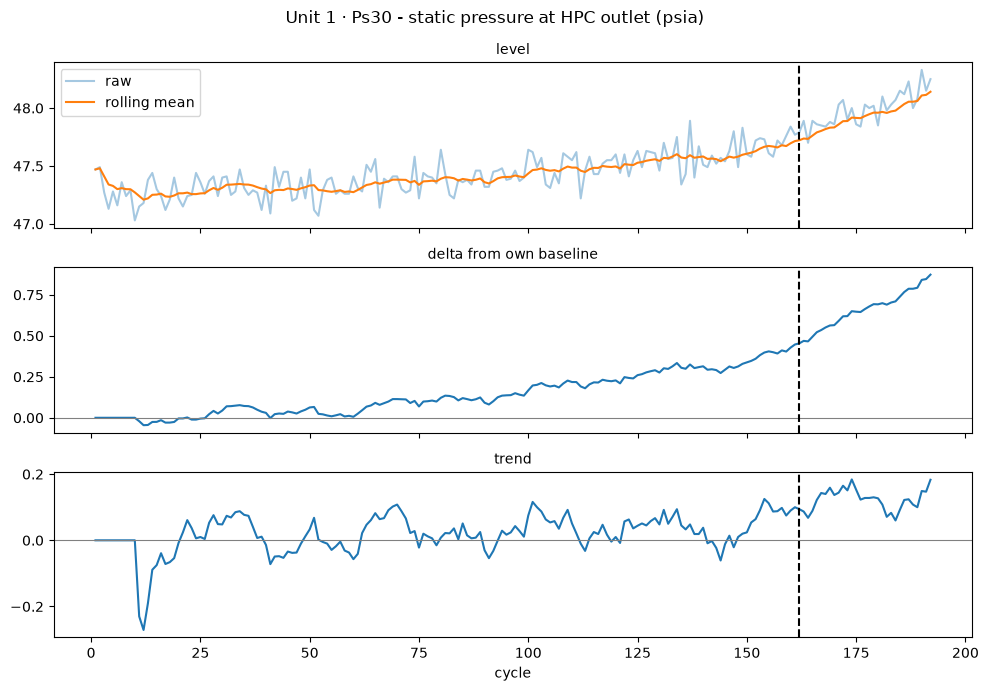

In [2]:
unit_id, sensor = 1, "sensor_11"
in_unit = train["unit"] == unit_id
unit, unit_features = train[in_unit], features[in_unit]
label_start = unit["cycle"].max() - HORIZON

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(unit["cycle"], unit[sensor], alpha=0.4, label="raw")
axes[0].plot(unit["cycle"], unit_features[f"{sensor}_mean{config.window}"], label="rolling mean")
axes[0].legend()
axes[1].plot(unit["cycle"], unit_features[f"{sensor}_delta_baseline"])
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[2].plot(unit["cycle"], unit_features[f"{sensor}_trend{config.trend_lag}"])
axes[2].axhline(0, color="grey", linewidth=0.8)
for ax, title in zip(axes, ["level", "delta from own baseline", "trend"], strict=True):
    ax.axvline(label_start, color="black", linestyle="--")
    ax.set_title(title, fontsize=10)
axes[2].set_xlabel("cycle")
fig.suptitle(f"Unit {unit_id} · {SENSOR_DESCRIPTIONS[sensor]}")
fig.tight_layout()
plt.show()

## 2. Do the features carry more signal than the raw sensors?

Spearman correlation with RUL, sensor by sensor. Smoothing usually increases the correlation simply because it removes noise, not because it adds new information. The question for `delta_baseline` is whether removing each unit's offset helps beyond smoothing.

In [3]:
def spearman_with_rul(column):
    return column.corr(train["rul"], method="spearman")


correlations = pd.DataFrame(
    {
        sensor: {
            "raw": spearman_with_rul(train[sensor]),
            "rolling_mean": spearman_with_rul(features[f"{sensor}_mean{config.window}"]),
            "trend": spearman_with_rul(features[f"{sensor}_trend{config.trend_lag}"]),
            "delta_baseline": spearman_with_rul(features[f"{sensor}_delta_baseline"]),
        }
        for sensor in config.sensors
    }
).T
correlations["name"] = [SENSOR_DESCRIPTIONS[s].split(" - ")[0] for s in correlations.index]
correlations.round(3)

,raw,rolling_mean,trend,delta_baseline,name
sensor_2,-0.629,-0.742,-0.341,-0.799,T24
sensor_3,-0.606,-0.750,-0.308,-0.788,T30
sensor_4,-0.702,-0.753,-0.448,-0.852,T50
sensor_7,0.679,0.731,0.420,0.836,P30
sensor_8,-0.574,-0.600,-0.407,-0.724,Nf
sensor_9,-0.322,-0.327,-0.291,-0.374,Nc
sensor_11,-0.718,-0.749,-0.511,-0.865,Ps30
sensor_12,0.693,0.729,0.466,0.841,phi
sensor_13,-0.573,-0.599,-0.393,-0.743,NRf
sensor_14,-0.202,-0.204,-0.199,-0.214,NRc


## 3. Leakage experiment, repeated with features

In notebook 01, with raw sensors, a random row split and a split by unit gave the same PR-AUC. Rolling features make neighbouring rows share information (overlapping windows), so the risk should now be larger. Same diagnostic model, five folds each.

The features are computed once on the full training set. That is legitimate because each row only uses its own unit's past; what changes between the two experiments is only which rows end up in validation.

The model here is a fixed diagnostic (`n_estimators=100` to keep it fast); the model comparison is block 1.3. This cell takes a few minutes.

In [4]:
y = train[LABEL_COLUMN]
model = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=42)
unit_folds = unit_group_kfold(train, n_splits=5)

fold_summary = pd.DataFrame(
    [
        {"fold": i, "units": train["unit"].iloc[idx].nunique(), "positive_rate": y.iloc[idx].mean()}
        for i, (_, idx) in enumerate(unit_folds, start=1)
    ]
)
print("Validation folds (no stratification needed: every unit has HORIZON + 1 positive cycles)")
print(fold_summary.round(3).to_string(index=False))

splits = {
    "random rows (KFold, shuffled)": KFold(n_splits=5, shuffle=True, random_state=42),
    "whole units (GroupKFold)": unit_folds,
}
leakage = pd.DataFrame(
    {
        name: cross_val_score(model, features, y, cv=cv, scoring="average_precision")
        for name, cv in splits.items()
    }
).T
leakage.columns = [f"fold_{i}" for i in range(1, leakage.shape[1] + 1)]
leakage.assign(mean=leakage.mean(axis=1), std=leakage.std(axis=1)).round(3)

Validation folds (no stratification needed: every unit has HORIZON + 1 positive cycles)
 fold  units  positive_rate
    1     20           0.15
    2     20           0.15
    3     20           0.15
    4     20           0.15
    5     20           0.15


,fold_1,fold_2,fold_3,fold_4,fold_5,mean,std
"random rows (KFold, shuffled)",0.991,0.994,0.994,0.996,0.994,0.994,0.001
whole units (GroupKFold),0.960,0.981,0.974,0.979,0.970,0.973,0.008


## 4. Should the age of the unit (`cycle`) be a feature?

The age of a unit is known at prediction time, so using it is not leakage. The risk is different: in this fleet every unit fails between cycle 128 and 362, so the model could learn "old units fail" instead of reading their health, and that would not transfer to units with a different life.

Decision rule, fixed **before** looking at the result: `cycle` is added only if it improves grouped PR-AUC by more than one standard deviation across folds.

In [5]:
def grouped_pr_auc(feature_matrix):
    scores = cross_val_score(model, feature_matrix, y, cv=unit_folds, scoring="average_precision")
    return pd.Series({"mean": scores.mean(), "std": scores.std()})


with_cycle = build_features(train, FeatureConfig(include_cycle=True))
pd.DataFrame(
    {
        "without cycle": grouped_pr_auc(features),
        "with cycle": grouped_pr_auc(with_cycle),
    }
).T.round(3)

,mean,std
without cycle,0.973,0.008
with cycle,0.981,0.006


## 5. Findings (block 1.2)

- **Raw vs features:** `delta_baseline` has the strongest correlation with RUL for all 14 sensors (|ρ| up to 0.865 for sensor 11, vs 0.718 raw). Smoothing (raw → rolling mean) adds up to +0.14, mostly for noisy or quantised sensors (3, 17, 2, 20, 21); removing each unit's offset (rolling mean → `delta_baseline`) adds a further +0.03 to +0.14, most for the fan speeds 13 and 8 and for sensors 11, 12 and 7. Sensors 9 and 14 stay far below the rest (−0.37 / −0.21): removing an offset cannot fix trends that go in opposite directions across units. `trend` is the weakest on its own (|ρ| 0.20–0.51): it is noisy and near zero for most of a unit's life, so any value it has is concentrated near failure.
- **Warm-up artefact:** the unit 1 plot shows a spike in `trend` around cycle 11, because early rolling means cover fewer than 10 cycles. Fixed after this run: `trend` is 0 until both windows are complete (cycle ≥ 20), with a dedicated test.
- **Leakage with features:** random rows 0.994 ± 0.001 vs whole units 0.973 ± 0.008. With overlapping windows the gap appears, as anticipated in notebook 01: each validation row has near-identical neighbours in training. The random split hides most of the real errors (1 − PR-AUC of 0.006 vs 0.027, about 4.5 times smaller) and is suspiciously stable. Grouped CV by unit is confirmed. Folds are balanced without stratification (positive rate 0.15 in every fold).
- **Cycle ablation:** 0.973 ± 0.008 without vs 0.981 ± 0.006 with `cycle`. The gain (+0.008) equals one standard deviation, so it does not exceed the pre-registered threshold: `cycle` is not used. A borderline result defaults to the simpler model, and the risk of learning this fleet's lifetimes instead of health remains.
- **Open questions:**
  - Raw sensors vs engineered features under the same protocol (0.961 in notebook 01 used a single split and a different forest, so it is not a fair comparison) → block 1.3.
  - How do validation scores (15% prevalence) translate to the test set (2.5%)? → block 1.3.
  - Does `trend` add value beyond `delta_baseline`, and how do the redundant pairs (8/13, 9/14) split attributions? → block 1.5.